# Datos sintéticos del proyecto: qué son, cómo se crean y para qué sirven

**Equipo 39 · Proyecto Integrador MNA**

Este notebook explica, para alguien que no conoce el proyecto, los **datos sintéticos** que usamos. Se puede ejecutar completo de principio a fin (*Run All*) y tarda menos de un minuto.

**En tres frases:**
1. Queremos medir qué tan rígido es el material de una viga microscópica (su **módulo de Young, E**) a partir de cómo vibra.
2. Las fórmulas que se usan para eso suponen una viga "perfecta", y las vigas reales no lo son; eso produce errores en E.
3. Para estudiar esos errores fabricamos datos de vigas "imperfectas" por computadora, donde **sí conocemos el E verdadero**, y así podemos medir cuánto se equivoca cada método.

### Contenido
1. [Nombres y términos](#1.-Nombres-y-términos)
2. [El problema](#2.-El-problema)
3. [Qué se mide en una viga que vibra](#3.-Qué-se-mide-en-una-viga-que-vibra)
4. [Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto](#4.-Cómo-calculamos-la-vibración-y-cómo-sabemos-que-el-cálculo-es-correcto)
5. [Los cuatro generadores: vigas perfectas e imperfectas](#5.-Los-cuatro-generadores:-vigas-perfectas-e-imperfectas)
6. [Qué tan imperfectas: la severidad](#6.-Qué-tan-imperfectas:-la-severidad)
7. [Un conjunto de datos, paso a paso](#7.-Un-conjunto-de-datos,-paso-a-paso)
8. [Cómo se usarán los datos](#8.-Cómo-se-usarán-los-datos)
9. [Limitaciones y pendientes](#9.-Limitaciones-y-pendientes)

## 1. Nombres y términos

A lo largo del notebook usamos algunos nombres cortos. Aquí están todos; cada sección los vuelve a explicar con más detalle.

**Física y dispositivos**

| Término | Significado |
|---|---|
| **MEMS** | Sistemas microelectromecánicos: piezas mecánicas del tamaño de micras fabricadas como chips |
| **Viga en voladizo** | Viga sujeta de un solo extremo, como un trampolín |
| **Viga biempotrada** | Viga sujeta de ambos extremos, como un puente |
| **Módulo de Young, E** | Qué tan rígido es un material. Es el número que queremos medir |
| **Tensión residual, σ₀** | Esfuerzo interno que queda en la viga después de fabricarla, sin que nadie se lo aplique, porque la película del material y la oblea se contraen de forma distinta al enfriarse. Si la deja estirada (tensión) la viga vibra más rápido; si la deja comprimida, más lento, y con demasiada compresión se pandea. Importa sobre todo en vigas biempotradas, porque en un voladizo el extremo libre deja que el material se relaje |
| **Modo de vibración** | Cada una de las maneras naturales en que puede vibrar una viga. El modo 1 es el más simple y lento; los modos 2, 3, … son patrones más complejos, con puntos intermedios que no se mueven (nodos), y cada uno vibra más rápido que el anterior. Cada modo tiene su propia frecuencia natural ω |
| **Forma modal** | El perfil que toma la viga cuando vibra en un modo, como si se congelara en el instante de máxima deformación: indica cuánto se mueve cada punto a lo largo de la viga. Se mide en N puntos (por ejemplo, con un vibrómetro láser). Solo importa la forma, no el tamaño, porque la amplitud depende de qué tan fuerte se excite la viga; por eso se normaliza a un máximo de 1 |
| **ξ** (xi) | Posición a lo largo de la viga, de 0 (soporte) a 1 (punta) |
| **Euler–Bernoulli** | La ecuación estándar de vibración de una viga delgada: el "modelo simple" |
| **Timoshenko** | Una versión más completa que agrega la deformación por cortante; importa en vigas cortas y gruesas |



**Los generadores de datos (M0–M3).** Cada uno es una forma distinta de fabricar datos de una viga; M0 es perfecta y M1–M3 tienen una imperfección que el modelo simple ignora:

| Nombre | Viga que simula |
|---|---|
| **M0** | Viga perfecta: lo que supone el modelo simple. Sirve de control |
| **M1** | El soporte gira un poco, como un resorte |
| **M2** | Viga corta y gruesa, donde importa el cortante (Timoshenko) |
| **M3** | El espesor cambia a lo largo de la viga |

**Niveles de severidad (s1–s6).** Solo para M1: seis grados de flexibilidad del soporte, de casi rígido (s1) a muy flexible (s6). Cada nivel corresponde a un error en E de 1, 2.5, 5, 10, 15 y 25% si se usa la fórmula ideal. La flexibilidad se describe con el número **κ_θ** (kappa theta): grande = soporte rígido, pequeño = soporte flexible.

**Niveles de método (L0–L3).** Agrupan los métodos que se van a comparar según cuánto desconfían del modelo simple:

| Nombre | Idea |
|---|---|
| **L0** | Confía totalmente en el modelo simple |
| **L1** | Permite que los datos se aparten un poco de la física |
| **L2** | Agrega un término genérico de corrección |
| **L3** | Agrega la física que le falta al modelo simple |

**Datos y experimento**

| Término | Significado |
|---|---|
| **Datos sintéticos** | Datos fabricados por computadora con un modelo físico, donde conocemos la respuesta correcta |
| **Mala especificación** | La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos |
| **Severidad** | Qué tan grande es la mala especificación, medida como el error en E que produce |
| **Ruido** | Error aleatorio que se suma a las mediciones simuladas: 2% en las formas modales y 0.03% en las frecuencias |
| **Semilla** | Número que fija el ruido aleatorio: misma semilla, mismos datos |
| **N** | Número de puntos donde se mide la forma modal |
| **PINN** | Red neuronal informada por la física: una red que se entrena respetando una ecuación física |
| **λ, κ_θ, W** | Versiones sin unidades de la frecuencia, la rigidez del soporte y el desplazamiento (sección 8) |

**Fuentes que se mencionan**

| Nombre | Qué es |
|---|---|
| **NIST** | Instituto Nacional de Estándares y Tecnología de EE. UU. |
| **RM 8096** | Material de referencia del NIST: un chip con vigas de óxido de silicio cuya geometría usamos |
| **M-TEST** | Método de medición de propiedades de MEMS (Osterberg y Senturia, 1997); de ahí sale el error típico de 5% por el soporte |
| **Kobrinsky et al. (2000)** | Artículo con valores medidos de la rigidez de soportes de vigas MEMS |

### Preparación

Esta celda localiza el código del proyecto (`src/pinn_mems`) y carga las librerías. Funciona aunque el paquete no esté instalado, siempre que el notebook se abra desde el repositorio. Requiere `numpy`, `scipy`, `pyyaml`, `matplotlib` y `pandas`.

In [1]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

import math
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems import Conjunto, Soporte, Viga, cargar_config, generar, resolver_modos
from pinn_mems.adimensional import Escalas
from pinn_mems.eigensolver import Timoshenko
from pinn_mems.severidad import severidad

CONFIGS = RAIZ / "datos" / "sinteticos" / "configs"
CALIBRACION = pd.read_csv(RAIZ / "datos" / "sinteticos" / "calibracion.csv")

# Paleta fija para todas las gráficas (azul, naranja, verde)
COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
})
pd.set_option("display.precision", 2)
print("Repositorio:", RAIZ)

Repositorio: /home/mnlvzqz/code/Integrador/team39-datos-sinteticos


## 2. El problema

Los fabricantes de chips MEMS necesitan conocer el módulo de Young E de sus materiales, porque de él depende cómo se comportan sus dispositivos. Una forma estándar de medirlo es **hacer vibrar una viga microscópica** y medir su frecuencia: una viga más rígida vibra más rápido. Con una fórmula se despeja E a partir de la frecuencia.

El problema es que esa fórmula supone una viga **ideal**: espesor perfectamente uniforme y un soporte que no se mueve nada. En la realidad el soporte cede un poco, el espesor varía, etc. La fórmula no sabe nada de eso y atribuye cualquier diferencia a E, así que **el E calculado sale sesgado**. Por ejemplo, el Instituto Nacional de Estándares de EE. UU. (NIST) midió vigas de 200, 300 y 400 µm del mismo material y obtuvo un E distinto según la longitud, un síntoma típico de este problema.

**La pregunta del proyecto:** ¿qué métodos (clásicos o con redes neuronales PINN) extraen mejor E cuando el modelo físico está un poco equivocado?

**Por qué datos sintéticos:** con datos reales nunca sabemos cuál es el E verdadero, así que no podemos medir el error de un método. Con datos sintéticos sí:

```
  1. GENERAR             2. INVERTIR                    3. COMPARAR
  Viga "imperfecta"  →   Cada método estima E con   →   E estimado vs. E verdadero
  con E conocido         el modelo ideal (simple)       = error del método
```

La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos se llama **mala especificación**. Es exactamente lo que queremos estudiar.

## 3. Qué se mide en una viga que vibra

Usamos como referencia la geometría de un material de referencia real del NIST (**RM 8096**): vigas de óxido de silicio, del tamaño de un cabello de ancho y unas 30 veces más delgadas.

In [2]:
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0)

pd.DataFrame({
    "valor": ["300 µm", "28 µm", "2.743 µm", "2200 kg/m³", "70 GPa"],
    "significado": ["longitud", "ancho", "espesor", "densidad del óxido de silicio",
                    "módulo de Young (valor verdadero)"],
}, index=["L", "b", "h", "ρ", "E"])

,valor,significado
L,300 µm,longitud
b,28 µm,ancho
h,2.743 µm,espesor
ρ,2200 kg/m³,densidad del óxido de silicio
E,70 GPa,módulo de Young (valor verdadero)


De cada viga se pueden medir dos cosas:

- **Frecuencias** de los primeros modos (ω₁, ω₂, ω₃): qué tan rápido vibra en cada forma.
- **Formas modales**: el perfil de la viga en cada modo, medido en N puntos a lo largo de ella (con un vibrómetro láser, por ejemplo).

Usamos la posición adimensional **ξ = x/L**, que va de 0 (soporte) a 1 (punta). Así todas las vigas se describen en la misma escala.

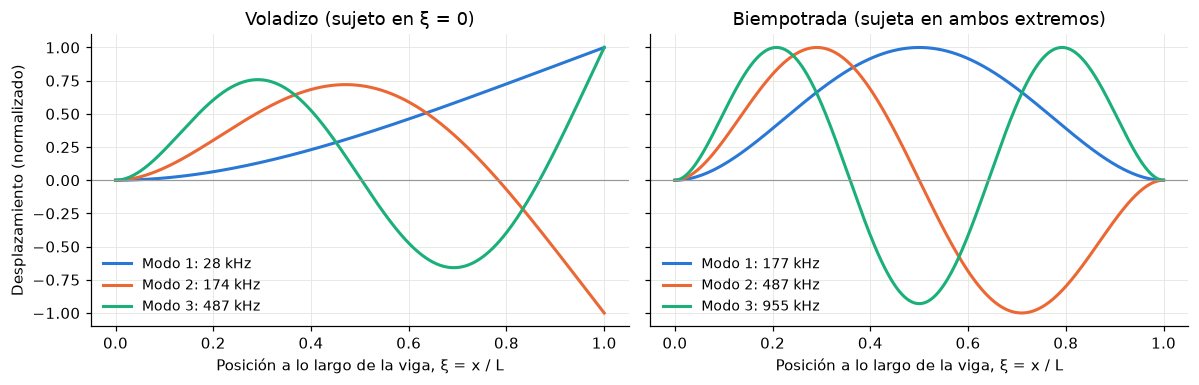

In [3]:
voladizo = resolver_modos(viga, "voladizo")
biempotrada = resolver_modos(viga, "biempotrada")

xi = np.linspace(0, 1, 400)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for eje, (nombre, modos) in zip(ejes, [("Voladizo (sujeto en ξ = 0)", voladizo),
                                        ("Biempotrada (sujeta en ambos extremos)", biempotrada)]):
    w = modos.forma(xi)
    for m in range(3):
        eje.plot(xi, w[m], color=COLORES[m],
                 label=f"Modo {m + 1}: {modos.frecuencias_hz[m] / 1e3:.0f} kHz")
    eje.axhline(0, color="#999", linewidth=0.8)
    eje.set_title(nombre)
    eje.set_xlabel("Posición a lo largo de la viga, ξ = x / L")
    eje.legend(frameon=False, fontsize=9)
ejes[0].set_ylabel("Desplazamiento (normalizado)")
fig.tight_layout()

Las formas tienen **amplitud arbitraria** (depende de qué tan fuerte se excite la viga), así que las normalizamos para que su valor máximo sea 1. Lo que importa es su forma y su frecuencia.

## 4. Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto

La vibración de una viga delgada se describe con la **ecuación de Euler–Bernoulli**:

  E·I·w⁗ − N·w″ − ω²·ρA·w = 0

donde w es el desplazamiento, I y A dependen de la sección (b, h), N es la tensión axial y ω la frecuencia. El código la resuelve con **elementos finitos**: divide la viga en 200 tramos, resuelve un problema de álgebra lineal y obtiene frecuencias y formas en milisegundos.

Antes de confiar en el código, lo comparamos con **soluciones exactas de libro de texto**. Para vigas ideales, ω = (βL)²·√(EI / ρAL⁴), con valores βL conocidos. El proyecto exige un error menor a 0.1%; obtenemos errores un millón de veces menores. Hay muchas más pruebas automáticas en `tests/` (con tensión, pandeo, soportes flexibles, cortante y conicidad).

In [4]:
raices = {"voladizo": [1.8751040687, 4.6940911330, 7.8547574382],
          "biempotrada": [4.7300407449, 7.8532046241, 10.9956078380]}
escala = math.sqrt(viga.EI / (viga.rho * viga.A * viga.L**4))
filas = []
for nombre, modos in [("voladizo", voladizo), ("biempotrada", biempotrada)]:
    for m in range(3):
        exacta = raices[nombre][m] ** 2 * escala
        filas.append({"estructura": nombre, "modo": m + 1,
                      "exacta (kHz)": exacta / (2 * np.pi * 1e3),
                      "calculada (kHz)": modos.frecuencias_hz[m] / 1e3,
                      "error relativo": f"{abs(modos.omega[m] / exacta - 1):.1e}"})
pd.DataFrame(filas).set_index(["estructura", "modo"])

exacta (kHz)  calculada (kHz) error relativo
estructura  modo                                              
voladizo    1            27.77            27.77        2.5e-08
            2           174.04           174.04        1.3e-09
            3           487.32           487.32        1.5e-09
biempotrada 1           176.72           176.72        1.5e-09
            2           487.13           487.13        1.5e-09
            3           954.97           954.97        6.3e-09

## 5. Los cuatro generadores: vigas perfectas e imperfectas

Los datos se generan con cuatro modelos, de M0 (perfecto) a M3. Los métodos que evaluaremos **siempre** usan el modelo simple (M0). Cada generador agrega una imperfección real que el modelo simple ignora:

| Generador | Qué agrega | Situación real | Cuántos niveles |
|---|---|---|---|
| **M0** | Nada: viga ideal | Control: todos los métodos deberían acertar | 1 |
| **M1** | El soporte **gira y/o se desplaza un poco**, como un resorte, la viga se comporta como si fuera un poco más larga y vibra más lento | El anclaje de una viga real nunca es perfectamente rígido | **6** (eje principal) |
| **M2** | **Cortante** e inercia de rotación (teoría de Timoshenko) | Vigas cortas y gruesas | 1 |
| **M3** | El espesor **varía linealmente** a lo largo de la viga | El grabado químico no es uniforme en el chip | 1 |

M1 es el caso principal porque es la explicación más probable del efecto que vio el NIST. M2 y M3 son una prueba de control: *¿el método que funciona bien con M1 sigue funcionando cuando el error tiene otra causa?*

A simple vista las formas de M1–M3 son casi idénticas a las de M0. Por eso graficamos la **diferencia** con M0: es la "huella" de cada imperfección, lo que un buen método tendría que detectar.

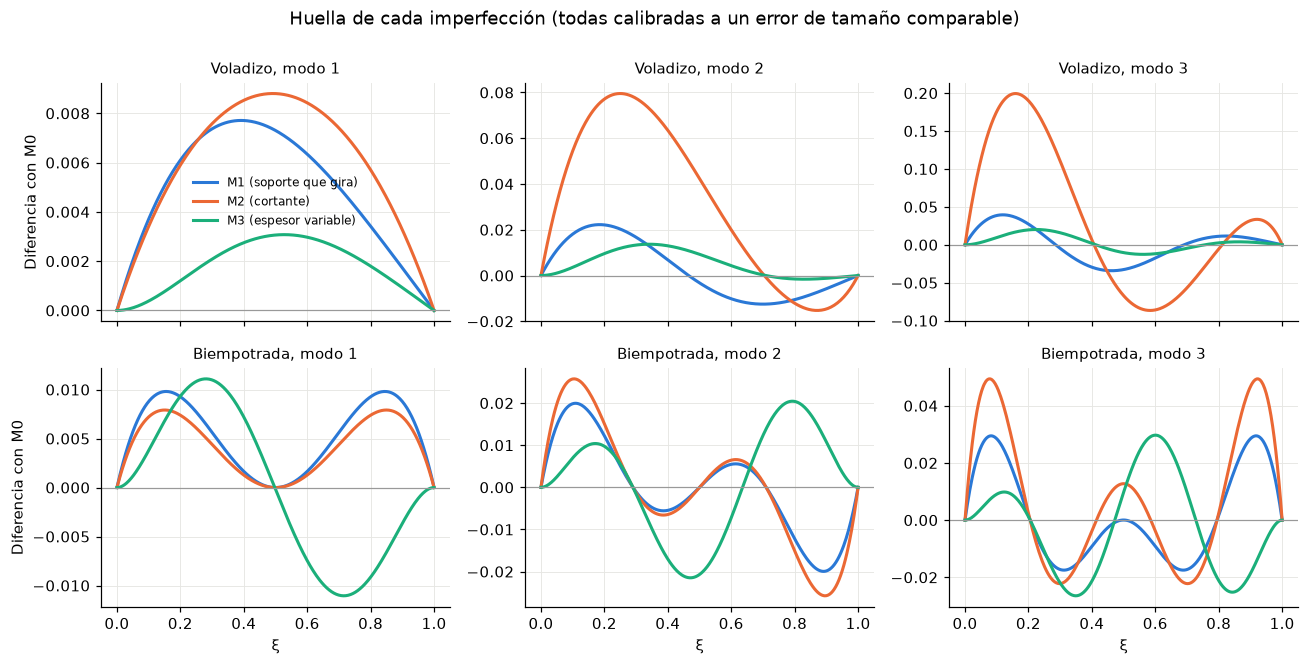

In [5]:
def fila_cal(nombre):
    return CALIBRACION.query("nombre == @nombre").iloc[0]

fig, ejes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for fila_ejes, est in zip(ejes, ["voladizo", "biempotrada"]):
    m0 = resolver_modos(viga, est).forma(xi)
    corta = Viga(**{**viga.__dict__, "L": float(fila_cal(f"m2_{est}").L)})
    huellas = {
        "M1 (soporte que gira)":
            resolver_modos(viga, est, Soporte(kappa_theta=float(fila_cal(f"m1_{est}_s3").kappa_theta))).forma(xi) - m0,
        "M2 (cortante)":
            resolver_modos(corta, est, timoshenko=Timoshenko()).forma(xi) - resolver_modos(corta, est).forma(xi),
        "M3 (espesor variable)":
            resolver_modos(viga, est, alpha=float(fila_cal(f"m3_{est}").alpha)).forma(xi) - m0,
    }
    for m, eje in enumerate(fila_ejes):
        for c, (nombre, d) in enumerate(huellas.items()):
            eje.plot(xi, d[m], color=COLORES[c], label=nombre)
        eje.axhline(0, color="#999", linewidth=0.8)
        eje.set_title(f"{est.capitalize()}, modo {m + 1}", fontsize=10)
    fila_ejes[0].set_ylabel("Diferencia con M0")
for eje in ejes[-1]:
    eje.set_xlabel("ξ")
ejes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Huella de cada imperfección (todas calibradas a un error de tamaño comparable)", y=1.0)
fig.tight_layout()

**Qué se ve:**
- **M1** cambia la forma sobre todo cerca del soporte, que ahora puede girar.
- **M2** casi no afecta al modo 1, pero deforma mucho los modos 2 y 3.
- **M3** en la biempotrada rompe la simetría de la viga: cambia la forma, pero casi no la frecuencia.
- En la biempotrada, **M1 y M2 dejan huellas muy parecidas**. Un método podría confundir una causa con la otra; M2 sirve justamente para comprobarlo.

## 6. Qué tan imperfectas: la severidad

Para M1 necesitamos decidir **qué tan flexible** es el soporte. Lo medimos con la **severidad**: el error que comete quien calcula E con la fórmula ideal. Como la frecuencia al cuadrado es proporcional a E:

  error en E = (ω₁ de la viga imperfecta / ω₁ de la viga ideal)² − 1

La flexibilidad del soporte se describe con un número adimensional, **κ_θ** (kappa): grande = soporte casi rígido, pequeño = soporte muy flexible. Elegimos **6 niveles** (s1 a s6) con errores en E de 1, 2.5, 5, 10, 15 y 25%:

- **s3 = 5%**: el error típico por el soporte que reporta la literatura (M-TEST).
- **s5 = 15%**: equivale a que la viga se comporte como si fuera **12.4 µm más larga**, el mismo orden que sale de los datos reales del NIST (12–13 µm). Es decir, el nivel "realista".

,κ_θ,error en E (%),cambio de forma (%),alargamiento equivalente (µm)
config,,,,
m1_voladizo_s1,396.12,-1.00,0.62,0.75
m1_voladizo_s2,156.12,-2.50,1.53,1.90
m1_voladizo_s3,76.12,-5.00,2.96,3.87
m1_voladizo_s4,36.11,-10.00,5.56,8.01
m1_voladizo_s5,22.77,-15.00,7.87,12.44
m1_voladizo_s6,12.09,-25.00,11.79,22.37
m1_voladizo_s5_ku_anillo,22.77,-17.97,58.92,15.23
m1_voladizo_s5_ku_pilares_apilados,22.77,-15.86,35.28,13.23
m1_voladizo_s5_ku_pilares_laterales,22.77,-15.43,22.31,12.84


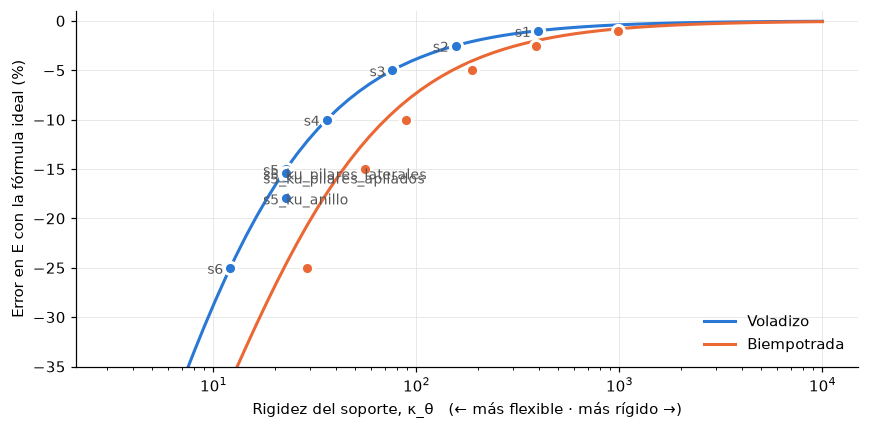

In [6]:
m1 = CALIBRACION.query("generador == 'M1'")
kappas = np.logspace(0.5, 4, 70)
fig, eje = plt.subplots(figsize=(8, 4))
for i, est in enumerate(["voladizo", "biempotrada"]):
    curva = [severidad(viga, est, Soporte(kappa_theta=k)).sesgo_E for k in kappas]
    eje.semilogx(kappas, 100 * np.array(curva), color=COLORES[i], label=est.capitalize())
    p = m1[m1.estructura == est]
    eje.plot(p.kappa_theta, 100 * p.sesgo_E, "o", color=COLORES[i], markersize=8,
             markeredgecolor="white", markeredgewidth=2)
for _, f in m1[m1.estructura == "voladizo"].iterrows():
    eje.annotate(f.nivel, (f.kappa_theta, 100 * f.sesgo_E), textcoords="offset points",
                 xytext=(-15, -4), color="#555", fontsize=9)
eje.set_xlabel("Rigidez del soporte, κ_θ   (← más flexible · más rígido →)")
eje.set_ylabel("Error en E con la fórmula ideal (%)")
eje.set_ylim(-35, 1)
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

tabla = m1.assign(error_E=100 * m1.sesgo_E, forma=100 * m1.diferencia_forma, dL=1e6 * m1.delta_L)
tabla = tabla[["nombre", "kappa_theta", "error_E", "forma", "dL"]]
tabla.columns = ["config", "κ_θ", "error en E (%)", "cambio de forma (%)", "alargamiento equivalente (µm)"]
tabla.set_index("config")

Dos observaciones:

- **La forma cambia mucho menos que la frecuencia.** En s1 y s2 el cambio de forma (≈1%) es menor que el ruido de medición que simulamos (2%). Un método que solo mire la forma casi no puede distinguir esos niveles de una viga perfecta.
- **M1 reproduce lo que vio el NIST.** Si el *mismo* soporte sostiene vigas de distinta longitud, las cortas sienten más su flexibilidad. La siguiente gráfica fija el soporte del nivel s5 y calcula el E que daría la fórmula ideal para vigas de 150 a 450 µm: E aparente sube con la longitud, igual que en las mediciones del NIST.

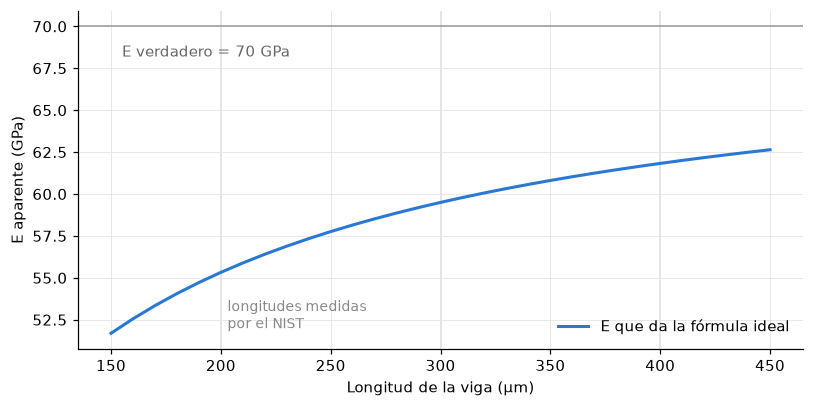

In [7]:
esc = Escalas.desde_viga(viga)
s5 = Soporte(kappa_theta=float(fila_cal("m1_voladizo_s5").kappa_theta))
k_theta_fisico, _ = esc.desde_soporte(s5)  # rigidez física del soporte, N·m/rad

longitudes = np.linspace(150e-6, 450e-6, 31)
E_aparente = []
for L in longitudes:
    v = Viga(**{**viga.__dict__, "L": L})
    E_aparente.append(viga.E * (1 + severidad(v, "voladizo", Soporte.desde_rigideces(v, k_theta_fisico, math.inf)).sesgo_E))

fig, eje = plt.subplots(figsize=(7.5, 3.8))
eje.plot(1e6 * longitudes, np.array(E_aparente) / 1e9, color=COLORES[0], label="E que da la fórmula ideal")
eje.axhline(viga.E / 1e9, color="#999", linewidth=1)
eje.text(155, viga.E / 1e9 - 1.8, "E verdadero = 70 GPa", color="#666")
for L in (200, 300, 400):
    eje.axvline(L, color="#ddd", linewidth=1, zorder=0)
eje.text(203, 52, "longitudes medidas\npor el NIST", color="#888", fontsize=9)
eje.set_xlabel("Longitud de la viga (µm)")
eje.set_ylabel("E aparente (GPa)")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

**Severidad de M2 y M3.** Se usa un solo nivel, igualado a s3 (5% de error en E):

- **M2:** en la viga del NIST el cortante es despreciable (0.01% en E). Para que importe hay que usar una viga **más corta** con el mismo espesor: 42 µm en la biempotrada y 14 µm en el voladizo.
- **M3:** en el voladizo, la variación de espesor que da 5% de error en E (±2%). En la biempotrada la frecuencia casi no reacciona, así que se iguala el **cambio de forma** de s3.

In [8]:
ref = CALIBRACION[CALIBRACION.nombre.str.match(r"m1_.*_s3|m2_|m3_")]
pd.DataFrame({
    "config": ref.nombre,
    "error en E (%)": 100 * ref.sesgo_E,
    "cambio en ω₃ (%)": 100 * ref.corrimiento_omega3,
    "cambio de forma (%)": 100 * ref.diferencia_forma,
}).set_index("config")

,error en E (%),cambio en ω₃ (%),cambio de forma (%)
config,,,
m1_voladizo_s3,-5.00e+00,-2.34e+00,2.96
m2_voladizo,-5.00e+00,-2.61e+01,12.51
m3_voladizo,-5.00e+00,-2.77e-01,1.47
m1_biempotrada_s3,-5.00e+00,-1.85e+00,1.82
m2_biempotrada,-5.00e+00,-9.19e+00,2.56
m3_biempotrada,-9.28e-03,-8.10e-03,1.82


**¿Y si el soporte también se desplaza?** En M1 hay dos resortes: uno de giro (κ_θ) y uno de desplazamiento vertical (κ_u). El eje principal solo usa el de giro (κ_u = ∞), porque su nivel s5 coincide con la rigidez de giro estimada para el chip real del NIST. Pero esos mismos datos reales se explican igual de bien con un soporte que se desplaza, así que no permiten fijar κ_u.

Para ver cuánto importaría, hay 6 conjuntos de **sensibilidad**: el nivel s5 más un resorte de desplazamiento tomado de tres tipos de soporte de la tesis de Deutsch (2002), llevados a la geometría del NIST. Son soportes de polisilicio distintos del anclaje del NIST y probablemente más blandos, así que marcan una cota de lo que podría pasar.

In [9]:
sens = CALIBRACION[CALIBRACION.nombre.str.contains(r"_s5(?:$|_ku_)")]
pd.DataFrame({
    "config": sens.nombre,
    "κ_u": sens.kappa_u,
    "error en E (%)": 100 * sens.sesgo_E,
    "cambio en ω₃ (%)": 100 * sens.corrimiento_omega3,
    "cambio de forma (%)": 100 * sens.diferencia_forma,
}).set_index("config")

,κ_u,error en E (%),cambio en ω₃ (%),cambio de forma (%)
config,,,,
m1_voladizo_s5,inf,-15.00,-6.15,7.87
m1_voladizo_s5_ku_anillo,188.23,-17.97,-39.53,58.92
m1_voladizo_s5_ku_pilares_apilados,658.79,-15.86,-21.69,35.28
m1_voladizo_s5_ku_pilares_laterales,1317.59,-15.43,-14.21,22.31
m1_biempotrada_s5,inf,-15.00,-5.33,5.24
m1_biempotrada_s5_ku_anillo,188.23,-94.39,-56.54,70.28
m1_biempotrada_s5_ku_pilares_apilados,658.79,-53.78,-43.61,54.58
m1_biempotrada_s5_ku_pilares_laterales,1317.59,-36.90,-32.48,42.83


Un soporte que se desplaza casi no cambia la frecuencia del modo 1 del voladizo (de −15 a −18 % de error en E), que es lo único que mide el Brazo 1 con datos reales. En cambio, transforma los **modos altos**: con el soporte más blando, el modo 3 del voladizo se vuelve casi un movimiento del propio soporte. En la viga biempotrada el efecto es mucho mayor, incluso en el modo 1. Por eso medir varias formas modales o varios modos ayudaría a distinguir el giro del desplazamiento del soporte.

## 7. Un conjunto de datos, paso a paso

Cada conjunto de datos se describe con un pequeño archivo de configuración (YAML) en `datos/sinteticos/configs/`. Hay 24: los 18 del eje principal (M0, M1 en 6 niveles, M2 y M3, cada uno para voladizo y biempotrada) y 6 de sensibilidad al desplazamiento del soporte (sección 6). Así se ve uno:

In [10]:
print((CONFIGS / "m1_voladizo_s3.yaml").read_text())

# M1, severidad s3 de 6: sesgo en E = -5.0%, ΔL = 3.87 µm.
# Generado por scripts/calibrar_severidad.py; no editar a mano.
nombre: m1_voladizo_s3
generador: M1
estructura: voladizo
params:
  E: 70000000000.0
  L: 0.0003
  b: 2.8e-05
  h: 2.743e-06
  rho: 2200.0
  sigma0: 0.0
soporte:
  kappa_theta: 76.1171
  kappa_u: .inf
muestreo:
  n_puntos: 100
  n_modos: 3
ruido:
  nivel: 0.02
  nivel_omega: 0.0003
  semilla: 0
malla:
  n_elem: 200



| Campo | Qué indica |
|---|---|
| `generador`, `estructura` | Qué viga simular: M0–M3, voladizo o biempotrada |
| `params` | Material y geometría en unidades SI (E en Pa, longitudes en m, densidad en kg/m³) y la tensión residual σ₀ (+10 MPa en la viga biempotrada; 0 en los voladizos, cuyo extremo libre no conserva tensión) |
| `soporte` | Solo M1: rigidez del soporte al giro (`kappa_theta`) y al desplazamiento (`kappa_u`); `.inf` significa perfectamente rígido |
| `muestreo` | Cuántos puntos y cuántos modos se miden |
| `ruido` | Nivel de ruido en las formas (`nivel`, 0.02 = 2%), en las frecuencias (`nivel_omega`, 0.0003 = 0.03%) y semilla |
| `malla` | En cuántos tramos divide el cálculo a la viga |

Con esa configuración, `generar()`:

1. Construye la viga y el generador indicados (aquí M1 con κ_θ = 76).
2. Calcula frecuencias y formas modales.
3. Muestrea las formas en N = 100 puntos.
4. Agrega **ruido de medición** gaussiano: 2% de la amplitud máxima de cada modo en las formas y 0.03% en cada frecuencia (la dispersión entre mediciones repetidas que reporta Marshall). La **semilla** fija los números aleatorios: con la misma semilla se obtienen exactamente los mismos datos.

Los datos no se guardan en git: cualquiera los puede regenerar idénticos con `python scripts/generar_sinteticos.py`.

Frecuencias (kHz): [ 27.08 169.85 476.02]


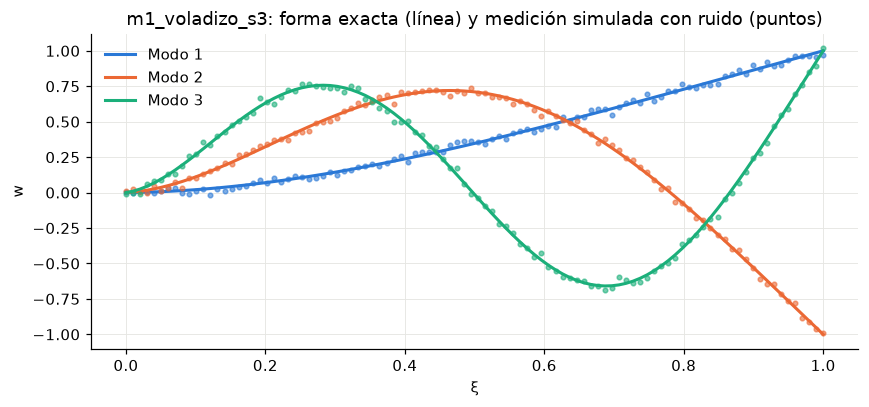

In [11]:
conjunto = generar(cargar_config(CONFIGS / "m1_voladizo_s3.yaml"))

fig, eje = plt.subplots(figsize=(8, 3.8))
for m in range(3):
    eje.plot(conjunto.xi, conjunto.w_limpia[m], color=COLORES[m], label=f"Modo {m + 1}")
    eje.plot(conjunto.xi, conjunto.w[m], "o", color=COLORES[m], markersize=3, alpha=0.6)
eje.set_title("m1_voladizo_s3: forma exacta (línea) y medición simulada con ruido (puntos)")
eje.set_xlabel("ξ")
eje.set_ylabel("w")
eje.legend(frameon=False)
fig.tight_layout()
print("Frecuencias (kHz):", np.round(conjunto.omega / (2 * np.pi * 1e3), 2))

### Estructura de los datos sintéticos

**Organización en el repositorio.** Lo que se guarda en git son las *recetas* (configuraciones) y la tabla de calibración; los datos se fabrican a partir de ellas:

```
datos/sinteticos/
├── configs/                 ← una receta YAML por conjunto de datos (24 archivos)
│   ├── m0_voladizo.yaml
│   ├── m1_voladizo_s1.yaml … m1_voladizo_s6.yaml
│   ├── m1_voladizo_s5_ku_anillo.yaml … (sensibilidad a κ_u)
│   ├── m2_voladizo.yaml
│   ├── m3_voladizo.yaml
│   └── … (lo mismo para biempotrada)
├── calibracion.csv          ← severidad de cada receta (error en E, cambio de forma, …)
└── generados/               ← archivos .npz producidos (no se guardan en git)
    └── m1_voladizo_s3.npz …
```

**Nombres.** Cada conjunto se llama `m<generador>_<estructura>[_s<nivel>]`; los de sensibilidad agregan `_ku_<soporte>`. Por ejemplo, `m1_biempotrada_s5` es una viga biempotrada con soporte flexible (M1) en el nivel de severidad 5, y `m3_voladizo` es un voladizo con espesor variable (M3).

**Catálogo.** El eje principal tiene 9 casos (M0, M1 en 6 niveles, M2 y M3) para cada una de las 2 estructuras, es decir, 18 conjuntos; además hay 6 de sensibilidad a κ_u:

In [12]:
catalogo = []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    cfg = cargar_config(ruta)
    p = cfg["params"]
    detalle = {
        "M0": "viga perfecta",
        "M1": f"soporte flexible, κ_θ = {cfg.get('soporte', {}).get('kappa_theta', 0):.1f}"
              + (f", κ_u = {cfg['soporte']['kappa_u']:.0f}" if math.isfinite(float(cfg.get('soporte', {}).get('kappa_u', math.inf))) else ""),
        "M2": f"cortante, viga de {float(p['L']) * 1e6:.1f} µm",
        "M3": f"espesor variable, α = {cfg.get('conicidad', {}).get('alpha', 0):.3f}",
    }[cfg["generador"]]
    catalogo.append({"conjunto": cfg["nombre"], "generador": cfg["generador"],
                     "estructura": cfg["estructura"], "qué simula": detalle,
                     "puntos N": cfg["muestreo"]["n_puntos"], "modos": cfg["muestreo"]["n_modos"],
                     "ruido": f"{100 * cfg['ruido']['nivel']:.0f}%", "semilla": cfg["ruido"]["semilla"]})
pd.DataFrame(catalogo).set_index("conjunto")

,generador,estructura,qué simula,puntos N,modos,ruido,semilla
conjunto,,,,,,,
m0_biempotrada,M0,biempotrada,viga perfecta,100,3,2%,0
m0_voladizo,M0,voladizo,viga perfecta,100,3,2%,0
m1_biempotrada_s1,M1,biempotrada,"soporte flexible, κ_θ = 985.3",100,3,2%,0
m1_biempotrada_s2,M1,biempotrada,"soporte flexible, κ_θ = 387.6",100,3,2%,0
m1_biempotrada_s3,M1,biempotrada,"soporte flexible, κ_θ = 188.3",100,3,2%,0
m1_biempotrada_s4,M1,biempotrada,"soporte flexible, κ_θ = 88.7",100,3,2%,0
m1_biempotrada_s5,M1,biempotrada,"soporte flexible, κ_θ = 55.5",100,3,2%,0
m1_biempotrada_s5_ku_anillo,M1,biempotrada,"soporte flexible, κ_θ = 55.5, κ_u = 188",100,3,2%,0
m1_biempotrada_s5_ku_pilares_apilados,M1,biempotrada,"soporte flexible, κ_θ = 55.5, κ_u = 659",100,3,2%,0


**Contenido de cada conjunto.** Cada archivo `.npz` (formato estándar de NumPy) tiene los mismos campos, así que todos los métodos del proyecto lo leen igual. Con N puntos de medición y 3 modos:

| Campo | Forma | Unidades | Contenido |
|---|---|---|---|
| `xi` | (N,) | sin unidades | Posiciones de medición, de 0 (soporte) a 1 (punta), igualmente espaciadas |
| `w` | (3, N) | sin unidades | Formas modales **con ruido**: lo que "mide" el método. Fila i = modo i + 1 |
| `w_limpia` | (3, N) | sin unidades | Las mismas formas sin ruido; solo para analizar resultados, nunca como entrada de un método |
| `omega` | (3,) | rad/s | Frecuencias naturales de los modos 1–3 **con ruido** (0.03%): lo que "mide" el método |
| `omega_limpia` | (3,) | rad/s | Las mismas frecuencias sin ruido; solo para analizar resultados |
| `nombre` | texto | — | Nombre del conjunto, p. ej. `m1_voladizo_s3` |
| `estructura` | texto | — | `voladizo` o `biempotrada` |
| `generador` | texto | — | `M0`, `M1`, `M2` o `M3` |
| `params` | texto JSON | SI | Parámetros físicos: E (la respuesta correcta), L, b, h, ρ, σ₀ y los del generador (κ_θ, κ_u, ν, α…) |
| `ruido` | texto JSON | — | Niveles de ruido (formas y frecuencias) y semilla usados |
| `config` | texto JSON | — | La receta YAML completa con la que se generó |
| `version` | texto | — | Versión del código (commit de git) que lo generó |

La siguiente celda guarda el conjunto del ejemplo, lo vuelve a leer directamente con NumPy y muestra lo que contiene:

In [13]:
with tempfile.TemporaryDirectory() as carpeta:
    ruta = conjunto.guardar(Path(carpeta) / "m1_voladizo_s3.npz")
    with np.load(ruta) as archivo:
        contenido = pd.DataFrame(
            [{"campo": k, "forma": str(archivo[k].shape) if archivo[k].ndim else "texto",
              "tipo": str(archivo[k].dtype)} for k in archivo.files]
        ).set_index("campo")
    copia = Conjunto.cargar(ruta)

print("Se guarda y se lee sin cambios:", np.array_equal(copia.w, conjunto.w) and copia.params == conjunto.params)
print("E verdadero guardado en el archivo:", copia.params["E"] / 1e9, "GPa")
contenido

Se guarda y se lee sin cambios: True
E verdadero guardado en el archivo: 70.0 GPa


,forma,tipo
campo,,
xi,"(100,)",float64
w,"(3, 100)",float64
w_limpia,"(3, 100)",float64
omega,"(3,)",float64
omega_limpia,"(3,)",float64
nombre,texto,<U14
estructura,texto,<U8
generador,texto,<U2
params,texto,<U138


## 8. Cómo se usarán los datos

Cada método recibe las mediciones (`w`, `omega`) y la geometría, y estima E **usando el modelo simple**. Como sabemos el E verdadero, medimos su error. Los métodos se organizan en cuatro niveles según cuánto "desconfían" del modelo simple:

| Nivel | Idea | Ejemplos |
|---|---|---|
| **L0** | Confía totalmente en el modelo simple | Fórmula estándar de la industria, ajuste clásico, PINN con la física fija |
| **L1** | Permite que los datos se aparten un poco de la física | PINN con la física "relajada" |
| **L2** | Agrega un término genérico de corrección | PINN o ajuste clásico con un término de discrepancia |
| **L3** | Agrega la física que falta | Ajuste o PINN que también estiman la flexibilidad del soporte |

### Un primer vistazo: el método más simple

Antes de los métodos sofisticados, apliquemos a cada conjunto la fórmula ideal (un método L0): despejar E de la primera frecuencia. Es lo que se hace hoy en la industria. **En M0 acierta; en las vigas imperfectas se equivoca**, y el error crece con la severidad. Los métodos del proyecto deben reducir ese error.

estructura,biempotrada,voladizo
caso,,
m0,0.00,0.0
m1_s1,-1.00,-1.0
m1_s2,-2.50,-2.5
m1_s3,-5.00,-5.0
m1_s4,-10.00,-10.0
m1_s5,-15.00,-15.0
m1_s6,-25.00,-25.0
m2,-5.00,-5.0
m3,-0.01,-5.0


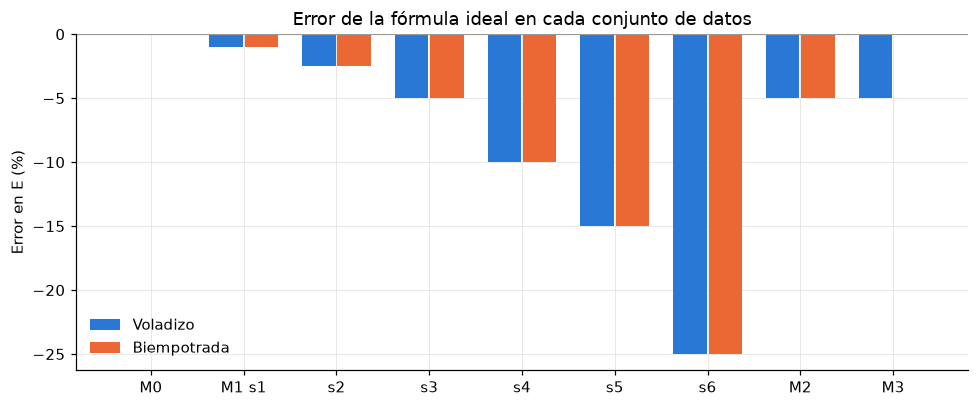

In [14]:
from pinn_mems.severidad import E_aparente

filas = []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    c = generar(cargar_config(ruta))
    v = Viga(**{k: c.params[k] for k in ("E", "L", "b", "h", "rho", "sigma0")})
    # E con el que el modelo ideal da la frecuencia (sin ruido) de este conjunto;
    # con tensión (biempotrada) la frecuencia no es ∝ √E y se invierte el modelo
    E_estimado = E_aparente(v, c.estructura, c.omega_limpia[0])
    filas.append({"config": c.nombre, "estructura": c.estructura,
                  "error en E (%)": 100 * (E_estimado / c.params["E"] - 1)})
resultados = pd.DataFrame(filas)

orden = ["m0", *[f"m1_s{i}" for i in range(1, 7)], "m2", "m3"]
resultados["caso"] = resultados.config.str.replace(r"_(voladizo|biempotrada)", "", regex=True)
pivote = resultados.pivot(index="caso", columns="estructura", values="error en E (%)").loc[orden]

fig, eje = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(orden))
for i, est in enumerate(["voladizo", "biempotrada"]):
    eje.bar(x + (i - 0.5) * 0.38, pivote[est], width=0.36, color=COLORES[i], label=est.capitalize())
eje.axhline(0, color="#999", linewidth=0.8)
eje.set_xticks(x, ["M0", "M1 s1", "s2", "s3", "s4", "s5", "s6", "M2", "M3"])
eje.set_ylabel("Error en E (%)")
eje.set_title("Error de la fórmula ideal en cada conjunto de datos")
eje.legend(frameon=False, loc="lower left")
fig.tight_layout()
pivote.round(2)

Fíjate en **M3 de la biempotrada**: la fórmula ideal da casi 0% de error, porque la frecuencia no cambia. Pero la forma sí cambió. Un método que use las formas debería notar que algo no cuadra; uno que use solo la frecuencia, no. Este tipo de contraste es lo que el proyecto quiere medir.

### El experimento completo

Cada método se evaluará en esta matriz (plan del proyecto, con las decisiones del equipo registradas en `contexto/bitacora-decisiones.md`):

| Eje | Valores |
|---|---|
| Generador y severidad | M0, M1 (s1–s6), M2, M3 → **9 casos** |
| Puntos medidos por viga, N | 5, 15, 40 |
| Estructuras medidas, k | 1 (voladizo de 300 µm) o 3 (voladizo de 300 µm + viga biempotrada de 300 µm con σ₀ = +10 MPa + voladizo de 200 µm, **con el mismo anclaje**) |
| Modos usados | 1 o 3 (cada conjunto guarda 3; el método elige) |
| Semillas de ruido | 10 (para separar el error sistemático del aleatorio) |
| Ruido | 2% en las formas y 0.03% en las frecuencias, fijo |

M2 usa vigas cortas que no forman un grupo realista, así que solo se evalúa con k = 1. En total son **510 corridas de datos** (8 casos × 3 N × 2 k × 10 semillas, más M2 con 3 N × 10 semillas); con los dos niveles de modos, 1020 corridas por método. Todas se generan con:

```bash
python scripts/generar_matriz.py   # 990 archivos .npz y un manifiesto en datos/sinteticos/generados/matriz/
```

### Preparación para la PINN: adimensionalización

Una red neuronal entrena mal cuando sus números tienen escalas muy distintas, y en una viga MEMS conviven valores de 10⁻²³ (momento de inercia, en m⁴) y de 10¹⁰ (E, en Pa). Por eso todo se reescribe con cantidades **sin unidades**, de tamaño parecido. El código (`pinn_mems.adimensional`) hace la conversión de ida y vuelta, y el solver usa internamente las mismas cantidades.

In [15]:
modos = resolver_modos(viga, "voladizo", s5)
w_tipico = 50e-9  # amplitud típica de vibración: 50 nm
M_tipico = viga.EI * w_tipico / viga.L**2
con_unidades = {"I (m⁴)": viga.I, "E (Pa)": viga.E, "ρA (kg/m)": viga.rho * viga.A,
                "ω₁ (rad/s)": modos.omega[0], "w (m)": w_tipico, "momento (N·m)": M_tipico}
sin_unidades = {"λ₁": esc.a_lambda(modos.omega[0]), "κ_θ": s5.kappa_theta,
                "W = w/h": esc.a_W(w_tipico), "momento adim.": esc.a_M(M_tipico), "θ = E/E_ref": 1.0}

def rango(d):
    return np.log10(max(d.values()) / min(d.values()))

print("Con unidades:", ", ".join(f"{k} = {v:.0e}" for k, v in con_unidades.items()))
print(f"  → abarcan {rango(con_unidades):.0f} órdenes de magnitud\n")
print("Sin unidades:", ", ".join(f"{k} = {v:.3g}" for k, v in sin_unidades.items()))
print(f"  → abarcan {rango(sin_unidades):.0f} órdenes de magnitud")

Con unidades: I (m⁴) = 5e-23, E (Pa) = 7e+10, ρA (kg/m) = 2e-07, ω₁ (rad/s) = 2e+05, w (m) = 5e-08, momento (N·m) = 2e-12
  → abarcan 33 órdenes de magnitud

Sin unidades: λ₁ = 10.5, κ_θ = 22.8, W = w/h = 0.0182, momento adim. = 0.0182, θ = E/E_ref = 1
  → abarcan 3 órdenes de magnitud


## 9. Limitaciones y pendientes

**Lo que ya está:** el modelo físico y su validación, los cuatro generadores, la calibración de severidad, el formato de datos y la adimensionalización. Todo tiene pruebas automáticas (`pytest`).

**La matriz completa del experimento ya se genera** (`scripts/generar_matriz.py`, 510 corridas). Lo siguiente es aplicar sobre ella los métodos de la escalera (L0–L3).

**Supuestos que hay que confirmar con fuentes:**
- La rigidez del soporte al **desplazamiento** (además del giro) se supone infinita. Hay que tomarla de Kobrinsky et al. (2000) y recalibrar con `scripts/calibrar_severidad.py`.
- La cifra de 5% de M-TEST (nivel s3) no se ha verificado contra la fuente original.
- El voladizo de M2 es muy corto (L/h ≈ 5): es un caso de estrés más que un dispositivo típico.

**Para reproducir todo:**
```bash
pip install -e ".[dev]"
pytest                                   # todas las pruebas
python scripts/calibrar_severidad.py     # recalcula los niveles de severidad
python scripts/generar_sinteticos.py     # genera los 24 conjuntos en datos/sinteticos/generados/
```